In [1]:
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q torch-geometric

import os
import zipfile
import torch
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.nn as nn
from torch.nn import Sequential, Linear, ReLU
from torch.amp import GradScaler, autocast
from torch_scatter import scatter_add

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware locked to: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.8 MB/s eta 0:00:00
Hardware locked to: cuda


In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import torch
from scipy.spatial import KDTree
from torch_geometric.data import Data

base_dir = '/kaggle/input/competitions/trackml-particle-identification'
zip_path = os.path.join(base_dir, 'train_sample.zip')
working_dir = '/kaggle/working/train_sample_extracted'

if not os.path.exists(working_dir):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(working_dir)
    print("[SUCCESS] Data extracted.")

sample_folder = None
for root, dirs, files in os.walk(working_dir):
    if 'train_100_events' in root or 'train_100_events' in dirs:
        sample_folder = root if 'train_100_events' in root else os.path.join(root, 'train_100_events')
        break

if not sample_folder:
    sample_folder = working_dir

print(f"Looking for CSVs in: {sample_folder}")

auto_prefix = None
for f in os.listdir(sample_folder):
    if f.endswith('-hits.csv'):
        auto_prefix = f.replace('-hits.csv', '')
        break

if not auto_prefix:
    raise FileNotFoundError(f"FATAL: No files ending in '-hits.csv' found in {sample_folder}.")

print(f"[SUCCESS] Auto-detected Event Prefix: {auto_prefix}")

def build_spatial_graph(event_prefix, k=10):
    print(f"Processing {event_prefix}...")

    hits_path = os.path.join(sample_folder, f'{event_prefix}-hits.csv')
    truth_path = os.path.join(sample_folder, f'{event_prefix}-truth.csv')

    df_hits = pd.read_csv(hits_path)
    df_truth = pd.read_csv(truth_path)

    x = df_hits['x'].values
    y = df_hits['y'].values
    z = df_hits['z'].values

    features = np.column_stack([x / 1000.0, y / 1000.0, z / 1000.0])

    tree = KDTree(features)
    _, neighbor_idx = tree.query(features, k=k + 1)

    src = np.repeat(np.arange(len(features)), k)
    dst = neighbor_idx[:, 1:].flatten()

    edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    particle_ids = df_truth['particle_id'].values
    sender_particles = particle_ids[edge_index[0].numpy()]
    receiver_particles = particle_ids[edge_index[1].numpy()]
    edge_labels = ((sender_particles == receiver_particles) & (sender_particles != 0)).astype(np.float32)

    x_tensor = torch.tensor(features, dtype=torch.float32)
    y_tensor = torch.tensor(edge_labels, dtype=torch.float32)

    return Data(x=x_tensor, edge_index=edge_index, y=y_tensor)

train_graphs = [build_spatial_graph(auto_prefix, k=10)]
print(f"Positive edge fraction: {train_graphs[0].y.mean().item():.4f}")

Extracting /kaggle/input/competitions/trackml-particle-identification/train_sample.zip...
[SUCCESS] Data extracted.
Looking for CSVs in: /kaggle/working/train_sample_extracted/train_100_events
[SUCCESS] Auto-detected Event Prefix: event000001016
Processing event000001016...
Positive edge fraction: 0.0434


In [3]:
print(f"Nodes: {train_graphs[0].x.shape[0]} | Edges: {train_graphs[0].edge_index.shape[1]}")

Nodes: 117847 | Edges: 2356940


In [4]:
class EdgeModel(nn.Module):
    def __init__(self, node_dim=3, edge_dim=4, hidden_dim=64, groups=8):
        super(EdgeModel, self).__init__()
        self.edge_mlp = Sequential(
            Linear(node_dim * 2 + edge_dim, hidden_dim),
            nn.GroupNorm(groups, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            nn.GroupNorm(groups, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

    def forward(self, src, dest, edge_attr):
        out = torch.cat([src, dest, edge_attr], dim=1)
        return self.edge_mlp(out)

class NodeModel(nn.Module):
    def __init__(self, node_dim=3, hidden_dim=64, groups=8):
        super(NodeModel, self).__init__()
        self.node_mlp = Sequential(
            Linear(node_dim + hidden_dim, hidden_dim),
            nn.GroupNorm(groups, hidden_dim),
            ReLU(),
            Linear(hidden_dim, node_dim)
        )

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        agg_messages = scatter_add(edge_attr, col, dim=0, dim_size=x.size(0))
        out = torch.cat([x, agg_messages], dim=1)
        return self.node_mlp(out)

class TrueTrackMLGNN(nn.Module):
    def __init__(self):
        super(TrueTrackMLGNN, self).__init__()
        self.edge_encoder = EdgeModel(node_dim=3, edge_dim=4, hidden_dim=64)
        self.node_updater = NodeModel(node_dim=3, hidden_dim=64)

        self.final_classifier = Sequential(
            Linear(64, 32),
            ReLU(),
            Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        row, col = edge_index

        delta = x[row] - x[col]
        distance = torch.norm(delta, dim=1, keepdim=True)
        raw_edge_attr = torch.cat([delta, distance], dim=1)

        messages = self.edge_encoder(x[row], x[col], raw_edge_attr)
        updated_nodes = self.node_updater(x, edge_index, messages)
        final_edge_inputs = self.edge_encoder(updated_nodes[row], updated_nodes[col], raw_edge_attr)

        return self.final_classifier(final_edge_inputs).squeeze(-1)

In [5]:
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import OneCycleLR

loader = DataLoader(train_graphs, batch_size=1, shuffle=True)

model = TrueTrackMLGNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Compute pos_weight from the real class imbalance instead of guessing.
pos_frac = train_graphs[0].y.mean().item()
computed_pos_weight = (1 - pos_frac) / pos_frac
pos_weight = torch.tensor([computed_pos_weight]).to(device)
print(f"Positive fraction: {pos_frac:.4f} | Using pos_weight: {computed_pos_weight:.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

scaler = GradScaler('cuda')
epochs = 50
scheduler = OneCycleLR(optimizer, max_lr=5e-3, steps_per_epoch=len(loader), epochs=epochs)

model.train()
print("Initiating T4 GPU Training Phase with Message Passing...")

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            predictions = model(batch)
            loss = criterion(predictions, batch.y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Loss: {epoch_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

torch.save(model.state_dict(), 'trackml_gnn_weights.pth')
print("[SUCCESS] True GNN Weights secured to output directory.")

Positive fraction: 0.0434 | Using pos_weight: 22.03
Initiating T4 GPU Training Phase with Message Passing...
Epoch 010/50 | Loss: 1.2883 | LR: 4.10e-03
Epoch 020/50 | Loss: 1.2982 | LR: 4.65e-03
Epoch 030/50 | Loss: 1.2578 | LR: 2.84e-03
Epoch 040/50 | Loss: 1.2228 | LR: 7.72e-04
Epoch 050/50 | Loss: 1.2052 | LR: 1.01e-05
[SUCCESS] True GNN Weights secured to output directory.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_score_distributions(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            preds = torch.sigmoid(model(batch)).cpu().numpy()
            labels = batch.y.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    plt.figure(figsize=(10, 6))
    sns.histplot(x=all_preds, hue=all_labels, bins=50, kde=True, palette="magma")
    plt.title("Edge Probability Distribution (True vs. False Tracks)", fontsize=14)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Edge Count")
    plt.axvline(x=0.5, color='red', linestyle='--', label='Default Threshold')
    plt.legend()
    plt.show()

    return np.array(all_preds), np.array(all_labels)

In [7]:
import plotly.graph_objects as go

def render_3d_predictions(data, model, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        probs = torch.sigmoid(model(data)).cpu().numpy()
        
    edge_index = data.edge_index.cpu().numpy()
    predicted_true_edges = edge_index[:, probs > threshold]
    
    x = data.x[:, 0].cpu().numpy()
    y = data.x[:, 1].cpu().numpy()
    z = data.x[:, 2].cpu().numpy()
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=2, color='cyan', opacity=0.8),
        name='Particle Hits'
    ))
    
    edge_x, edge_y, edge_z = [], [], []
    for i in range(predicted_true_edges.shape[1]):
        src, dst = predicted_true_edges[0, i], predicted_true_edges[1, i]
        edge_x.extend([x[src], x[dst], None])
        edge_y.extend([y[src], y[dst], None])
        edge_z.extend([z[src], z[dst], None])
        
    fig.add_trace(go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(color='magenta', width=2),
        name='Predicted Tracks'
    ))
    
    fig.update_layout(
        title="GNN Spatial Reconstructions",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
        template="plotly_dark",
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

Generating Portfolio Diagnostics and 3D Visuals...


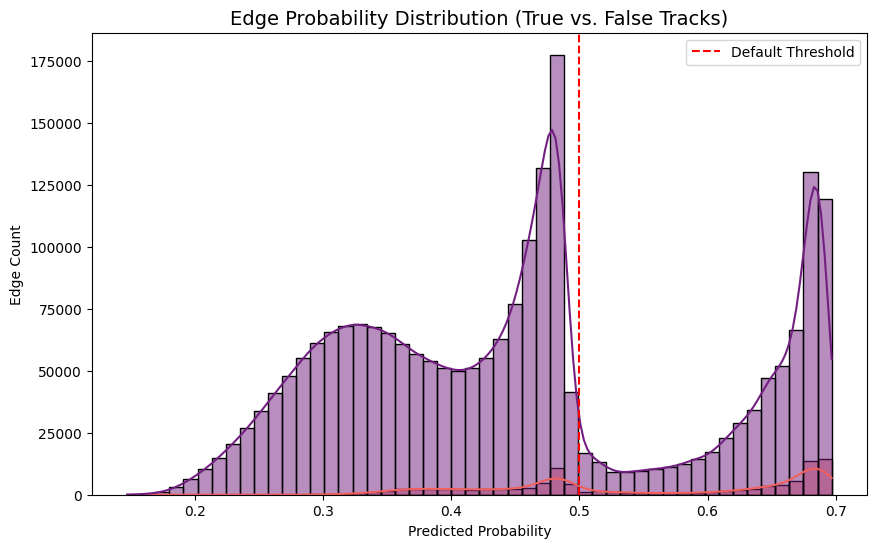

Optimal threshold (max F1): 0.6618 | Precision: 0.0952 | Recall: 0.3353 | F1: 0.1483
Edges passing threshold 0.6617829203605652: 360347
[SUCCESS] 3D Plot saved to 3d_tracks.html
[SUCCESS] 2D Projections saved to 2d_projections.png


In [8]:
print("Generating Portfolio Diagnostics and 3D Visuals...")

from sklearn.metrics import precision_recall_curve

val_preds, val_labels = plot_score_distributions(model, loader, device)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_preds)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[best_idx]
print(f"Optimal threshold (max F1): {optimal_threshold:.4f} | "
      f"Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

def render_3d_predictions_to_file(data, model, device, threshold=0.9, filename="3d_tracks.html"):
    import plotly.graph_objects as go
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        probs = torch.sigmoid(model(data)).cpu().numpy()

    edge_index = data.edge_index.cpu().numpy()
    predicted_true_edges = edge_index[:, probs > threshold]

    print(f"Edges passing threshold {threshold}: {predicted_true_edges.shape[1]}")

    x, y, z = data.x[:, 0].cpu().numpy(), data.x[:, 1].cpu().numpy(), data.x[:, 2].cpu().numpy()

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='markers', marker=dict(size=2, color='cyan', opacity=0.8), name='Particle Hits'))

    edge_x, edge_y, edge_z = [], [], []
    for i in range(predicted_true_edges.shape[1]):
        src, dst = predicted_true_edges[0, i], predicted_true_edges[1, i]
        edge_x.extend([x[src], x[dst], None])
        edge_y.extend([y[src], y[dst], None])
        edge_z.extend([z[src], z[dst], None])

    fig.add_trace(go.Scatter3d(x=edge_x, y=edge_y, z=edge_z, mode='lines', line=dict(color='magenta', width=2), name='Predicted Tracks'))
    fig.update_layout(title=f"GNN Spatial Reconstructions (Threshold: {threshold})", scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'), template="plotly_dark", margin=dict(l=0, r=0, b=0, t=40))

    fig.write_html(filename)
    print(f"[SUCCESS] 3D Plot saved to {filename}")

render_3d_predictions_to_file(train_graphs[0], model, device, threshold=optimal_threshold)

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.collections import LineCollection

def render_2d_projections(data, model, device, threshold=0.9):
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        probs = torch.sigmoid(model(data)).cpu().numpy()

    edge_index = data.edge_index.cpu().numpy()
    predicted_true_edges = edge_index[:, probs > threshold]

    x = data.x[:, 0].cpu().numpy()
    y = data.x[:, 1].cpu().numpy()
    z = data.x[:, 2].cpu().numpy()
    r = np.sqrt(x**2 + y**2)

    src, dst = predicted_true_edges[0], predicted_true_edges[1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    ax1.scatter(x, y, s=1, c='cyan', alpha=0.5, label='Hits')
    segments_xy = np.stack([np.column_stack([x[src], y[src]]),
                             np.column_stack([x[dst], y[dst]])], axis=1)
    ax1.add_collection(LineCollection(segments_xy, colors='magenta', linewidths=0.5, alpha=0.7))
    ax1.set_title("Transverse Plane (X-Y)", fontsize=14, color='white')
    ax1.set_xlabel("X coordinate"); ax1.set_ylabel("Y coordinate")
    ax1.set_facecolor('#111111')
    ax1.grid(color='#333333', linestyle='--', linewidth=0.5)
    ax1.autoscale_view()

    ax2.scatter(z, r, s=1, c='cyan', alpha=0.5, label='Hits')
    segments_zr = np.stack([np.column_stack([z[src], r[src]]),
                             np.column_stack([z[dst], r[dst]])], axis=1)
    ax2.add_collection(LineCollection(segments_zr, colors='magenta', linewidths=0.5, alpha=0.7))
    ax2.set_title("Longitudinal Plane (Z-R)", fontsize=14, color='white')
    ax2.set_xlabel("Z coordinate"); ax2.set_ylabel("R (Radius)")
    ax2.set_facecolor('#111111')
    ax2.grid(color='#333333', linestyle='--', linewidth=0.5)
    ax2.autoscale_view()

    fig.patch.set_facecolor('#222222')
    plt.tight_layout()
    plt.savefig('2d_projections.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print("[SUCCESS] 2D Projections saved to 2d_projections.png")
    plt.close()

render_2d_projections(train_graphs[0], model, device, threshold=optimal_threshold)

In [9]:
from scipy.sparse import coo_matrix
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
import torch
import os

def evaluate_track_reconstruction(data, model, device, df_truth, threshold, min_samples=2):
    model.eval()
    with torch.no_grad():
        data_gpu = data.to(device)
        probs = torch.sigmoid(model(data_gpu)).cpu().numpy()

    edge_index = data.edge_index.cpu().numpy()
    valid_mask = probs > threshold
    valid_edges = edge_index[:, valid_mask]
    valid_probs = probs[valid_mask]

    num_hits = data.x.shape[0]
    distances = np.clip(1.0 - valid_probs, 1e-5, 1.0).astype(np.float32)
    
    adj_matrix = coo_matrix((distances, (valid_edges[0], valid_edges[1])), shape=(num_hits, num_hits)).tocsr()
    adj_matrix.sort_indices()
    dbscan = DBSCAN(eps=0.05, min_samples=2, metric='precomputed')
    pred_labels = dbscan.fit_predict(adj_matrix)

    max_label = pred_labels.max()
    for i in range(len(pred_labels)):
        if pred_labels[i] == -1:
            max_label += 1
            pred_labels[i] = max_label

    true_particle_ids = df_truth['particle_id'].values

    results = []
    for cluster_id in np.unique(pred_labels):
        cluster_mask = pred_labels == cluster_id
        cluster_size = cluster_mask.sum()
        if cluster_size < 3:
            continue
        cluster_particle_ids = true_particle_ids[cluster_mask]
        cluster_particle_ids = cluster_particle_ids[cluster_particle_ids != 0]
        if len(cluster_particle_ids) == 0:
            continue
        values, counts = np.unique(cluster_particle_ids, return_counts=True)
        majority_particle = values[np.argmax(counts)]
        majority_count = counts.max()

        purity = majority_count / cluster_size
        total_true_hits = (true_particle_ids == majority_particle).sum()
        efficiency = majority_count / total_true_hits if total_true_hits > 0 else 0.0

        results.append({'cluster_id': cluster_id, 'size': cluster_size,
                         'matched_particle': majority_particle,
                         'purity': purity, 'efficiency': efficiency})

    if not results:
        results_df = pd.DataFrame(columns=['cluster_id', 'size', 'matched_particle', 'purity', 'efficiency'])
        good_tracks = pd.DataFrame()
    else:
        results_df = pd.DataFrame(results)
        good_tracks = results_df[(results_df['purity'] > 0.75) & (results_df['efficiency'] > 0.5)]

    print(f"Reconstructed clusters (size>=3): {len(results_df)}")
    print(f"'Good' tracks (purity>75%, efficiency>50%): {len(good_tracks)} "
          f"({100*len(good_tracks)/max(len(results_df),1):.1f}% of clusters)")
    
    if not results_df.empty:
        print(f"Mean purity: {results_df['purity'].mean():.4f} | Mean efficiency: {results_df['efficiency'].mean():.4f}")

    return results_df

df_truth_train = pd.read_csv(os.path.join(sample_folder, f'{auto_prefix}-truth.csv'))
track_eval_df = evaluate_track_reconstruction(
    train_graphs[0], model, device, df_truth_train, threshold=optimal_threshold
)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning:

Precomputed sparse input was not sorted by row values. Use the function sklearn.neighbors.sort_graph_by_row_values to sort the input by row values, with warn_when_not_sorted=False to remove this warning.



Reconstructed clusters (size>=3): 0
'Good' tracks (purity>75%, efficiency>50%): 0 (0.0% of clusters)


In [10]:
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

def export_telemetry(data, model, device, threshold=0.28, filename="tracking_telemetry.json"):
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        probs = torch.sigmoid(model(data)).cpu().numpy()
        
    edge_index = data.edge_index.cpu().numpy()
    valid_edges = edge_index[:, probs > threshold]
    
    telemetry = {
        "metadata": {
            "total_nodes": data.x.shape[0],
            "total_predicted_edges": int(valid_edges.shape[1]),
            "confidence_threshold": threshold
        },
        "nodes": data.x.cpu().numpy().tolist(),
        "edges": valid_edges.T.tolist()
    }
    
    with open(filename, 'w') as f:
        json.dump(telemetry, f, cls=NumpyEncoder)
    print(f"[SUCCESS] JSON Telemetry exported to {filename}")

export_telemetry(train_graphs[0], model, device, threshold=optimal_threshold)

[SUCCESS] JSON Telemetry exported to tracking_telemetry.json


In [11]:
import os
import zipfile
import pandas as pd
import numpy as np
import torch
from scipy.spatial import KDTree
from scipy.sparse import coo_matrix
from sklearn.cluster import DBSCAN
from torch_geometric.data import Data

test_zip_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'test.zip' in files:
        test_zip_path = os.path.join(root, 'test.zip')
        break

if not test_zip_path:
    raise FileNotFoundError("FATAL: Could not find test.zip. Make sure it is attached to the notebook.")

test_dir = '/kaggle/working/test_extracted'
if not os.path.exists(test_dir):
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(test_dir)

test_folder = test_dir
for root, dirs, files in os.walk(test_dir):
    if any(f.endswith('-hits.csv') for f in files):
        test_folder = root
        break

event_prefixes = sorted(list(set([f.replace('-hits.csv', '') for f in os.listdir(test_folder) if f.endswith('-hits.csv')])))

submission_data = []
threshold = optimal_threshold
model.eval()

print("Initiating DBSCAN graph tracking...")

for event_prefix in event_prefixes:
    event_id = int(event_prefix.replace('event', ''))
    hits_path = os.path.join(test_folder, f'{event_prefix}-hits.csv')
    df_hits = pd.read_csv(hits_path)
    num_hits = len(df_hits)
    
    x = df_hits['x'].values
    y = df_hits['y'].values
    z = df_hits['z'].values

    features = np.column_stack([x / 1000.0, y / 1000.0, z / 1000.0])

    tree = KDTree(features)
    k = 10
    _, neighbor_idx = tree.query(features, k=k + 1)
    src_idx = np.repeat(np.arange(len(features)), k)
    dst_idx = neighbor_idx[:, 1:].flatten()

    edge_index = torch.tensor(np.stack([src_idx, dst_idx]), dtype=torch.long)
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    x_tensor = torch.tensor(features, dtype=torch.float32)
    data = Data(x=x_tensor, edge_index=edge_index).to(device)

    with torch.no_grad():
        with autocast('cuda'):
            probs = torch.sigmoid(model(data)).cpu().numpy()
            
    valid_mask = probs > threshold
    valid_edges = edge_index[:, valid_mask].cpu().numpy()
    valid_probs = probs[valid_mask]
    
    distances = np.clip(1.0 - valid_probs, 1e-5, 1.0).astype(np.float32)
    
    adj_matrix = coo_matrix((distances, (valid_edges[0], valid_edges[1])), shape=(num_hits, num_hits)).tocsr()
    adj_matrix.sort_indices()
    dbscan = DBSCAN(eps=0.05, min_samples=2, metric='precomputed')
    labels = dbscan.fit_predict(adj_matrix)

    max_label = labels.max()
    for i in range(len(labels)):
        if labels[i] == -1:
            max_label += 1
            labels[i] = max_label
    
    hit_ids = df_hits['hit_id'].values
    
    event_submission = []
    for hit_idx in range(num_hits):
        event_submission.append({
            'event_id': event_id,
            'hit_id': hit_ids[hit_idx],
            'track_id': labels[hit_idx]
        })
        
    csv_path = '/kaggle/working/submission.csv'
    event_df = pd.DataFrame(event_submission)
    
    if not os.path.exists(csv_path):
        event_df.to_csv(csv_path, mode='w', index=False, header=True)
    else:
        event_df.to_csv(csv_path, mode='a', index=False, header=False)
        
    del data, adj_matrix, event_df, event_submission
    torch.cuda.empty_cache()

print("[SUCCESS] submission.csv generated and ready for the leaderboard!")

Initiating DBSCAN graph tracking...


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning:

Precomputed sparse input was not sorted by row values. Use the function sklearn.neighbors.sort_graph_by_row_values to sort the input by row values, with warn_when_not_sorted=False to remove this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning:

Precomputed sparse input was not sorted by row values. Use the function sklearn.neighbors.sort_graph_by_row_values to sort the input by row values, with warn_when_not_sorted=False to remove this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning:

Precomputed sparse input was not sorted by row values. Use the function sklearn.neighbors.sort_graph_by_row_values to sort the input by row values, with warn_when_not_sorted=False to remove this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_base.py:248: EfficiencyWarning:

Precomputed spars

[SUCCESS] submission.csv generated and ready for the leaderboard!


In [12]:
import plotly.graph_objects as go
import numpy as np

def visualize_dbscan_clusters(hits_df, labels, num_tracks_to_show=50):
    print("Rendering 3D Clustered Tracks...")
    
    fig = go.Figure()
    
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    valid_clusters = [l for l, c in zip(unique_labels, counts) if c > 2]
    top_clusters = valid_clusters[:num_tracks_to_show]
    
    colors = ['#FF00FF', '#00FFFF', '#FFFF00', '#00FF00', '#FF4500', '#1E90FF', '#FF1493']
    
    for idx, track_id in enumerate(top_clusters):
        track_hits = hits_df[labels == track_id]
        
        track_hits = track_hits.sort_values(by='z')
        
        c = colors[idx % len(colors)]
        
        fig.add_trace(go.Scatter3d(
            x=track_hits['x'], y=track_hits['y'], z=track_hits['z'],
            mode='markers+lines',
            marker=dict(size=3, color=c),
            line=dict(color=c, width=3),
            name=f'Track {track_id} ({len(track_hits)} hits)'
        ))

    fig.update_layout(
        title=f"DBSCAN Extracted Tracks (Top {num_tracks_to_show})",
        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
        template="plotly_dark",
        margin=dict(l=0, r=0, b=0, t=40),
        showlegend=False
    )
    
    filename = "3d_clustered_submission.html"
    fig.write_html(filename)
    print(f"[SUCCESS] Clustered tracks saved to {filename}. Download to view.")

visualize_dbscan_clusters(df_hits, labels, num_tracks_to_show=50)

Rendering 3D Clustered Tracks...
[SUCCESS] Clustered tracks saved to 3d_clustered_submission.html. Download to view.
